# 06. Chất lượng dữ liệu

**Mục tiêu:** Liệt kê các lỗi / điểm bất thường của dữ liệu và chấm điểm chất lượng 13 bảng theo 6 khía cạnh – điểm "trước tiền xử lý" để so sánh ở Giai đoạn 2.

**Bảng dữ liệu dùng:** 13 bảng (bỏ `sample_submission`)

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("06_chat_luong_du_lieu")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\06_chat_luong_du_lieu


Logic kiểm tra nằm trong `src/ds317/quality.py`:
`audit_findings` (danh sách lỗi), `dirtiness_metrics` (các chỉ số cho chart), `dq_rules` (từng quy tắc), `dq_scores` (bảng điểm).

In [2]:
from ds317.data import TABLES
from ds317.quality import audit_findings, dirtiness_metrics, dq_rules, dq_scores, DIMENSIONS

t = load_many(*[n for n in TABLES if n != "sample_submission"])
m = dirtiness_metrics(t)

## Dữ liệu có những lỗi / bất thường nào, mức độ bao nhiêu?

In [3]:
findings = audit_findings(t)
findings.to_csv(TAB / "audit_findings.csv", index=False, encoding="utf-8-sig")
findings

,bang,cot,loai_loi,so_dong,pct,muc_do,mo_ta
0,order_items,promo_id,Giá trị trống (NULL),438353,61.337,HIGH,"438,353 dòng trống"
1,order_items,promo_id_2,Giá trị trống (NULL),714463,99.971,HIGH,"714,463 dòng trống"
2,promotions,applicable_category,Giá trị trống (NULL),40,80.000,HIGH,40 dòng trống
3,orders vs shipments,order_status / order_id,Đơn đã giao nhưng không có shipment,564,0.087,HIGH,Đơn delivered/returned/shipped không có trong ...
4,sales,Revenue vs COGS,Ngày lỗ gộp (COGS > Revenue),382,9.966,CRITICAL,Biên gộp ngày thấp nhất -57.46%
5,order_items vs products,unit_price vs price,Giá bán khác giá niêm yết,714593,99.989,HIGH,unit_price khác products.price quá 0.01
6,order_items,discount_amount,Chiết khấu > giá trị dòng hàng,0,0.000,LOW,discount_amount > quantity*unit_price
7,payments vs order_items,payment_value,Lệch thanh toán nếu cộng phí ship,402126,62.158,INFO,"payment_value khớp tiền hàng net ở 646,945/646..."
8,returns vs order_items,return_quantity,Trả hàng phi lý,0,0.000,LOW,0 dòng trả nhiều hơn đã mua; 0 sản phẩm trả kh...
9,inventory,stock_on_hand / stockout_days / fill_rate / se...,Chỉ số tồn kho ngoài miền hợp lệ,0,0.000,MEDIUM,"tồn âm, stockout_days > 31, tỷ lệ ngoài [0, 1]"


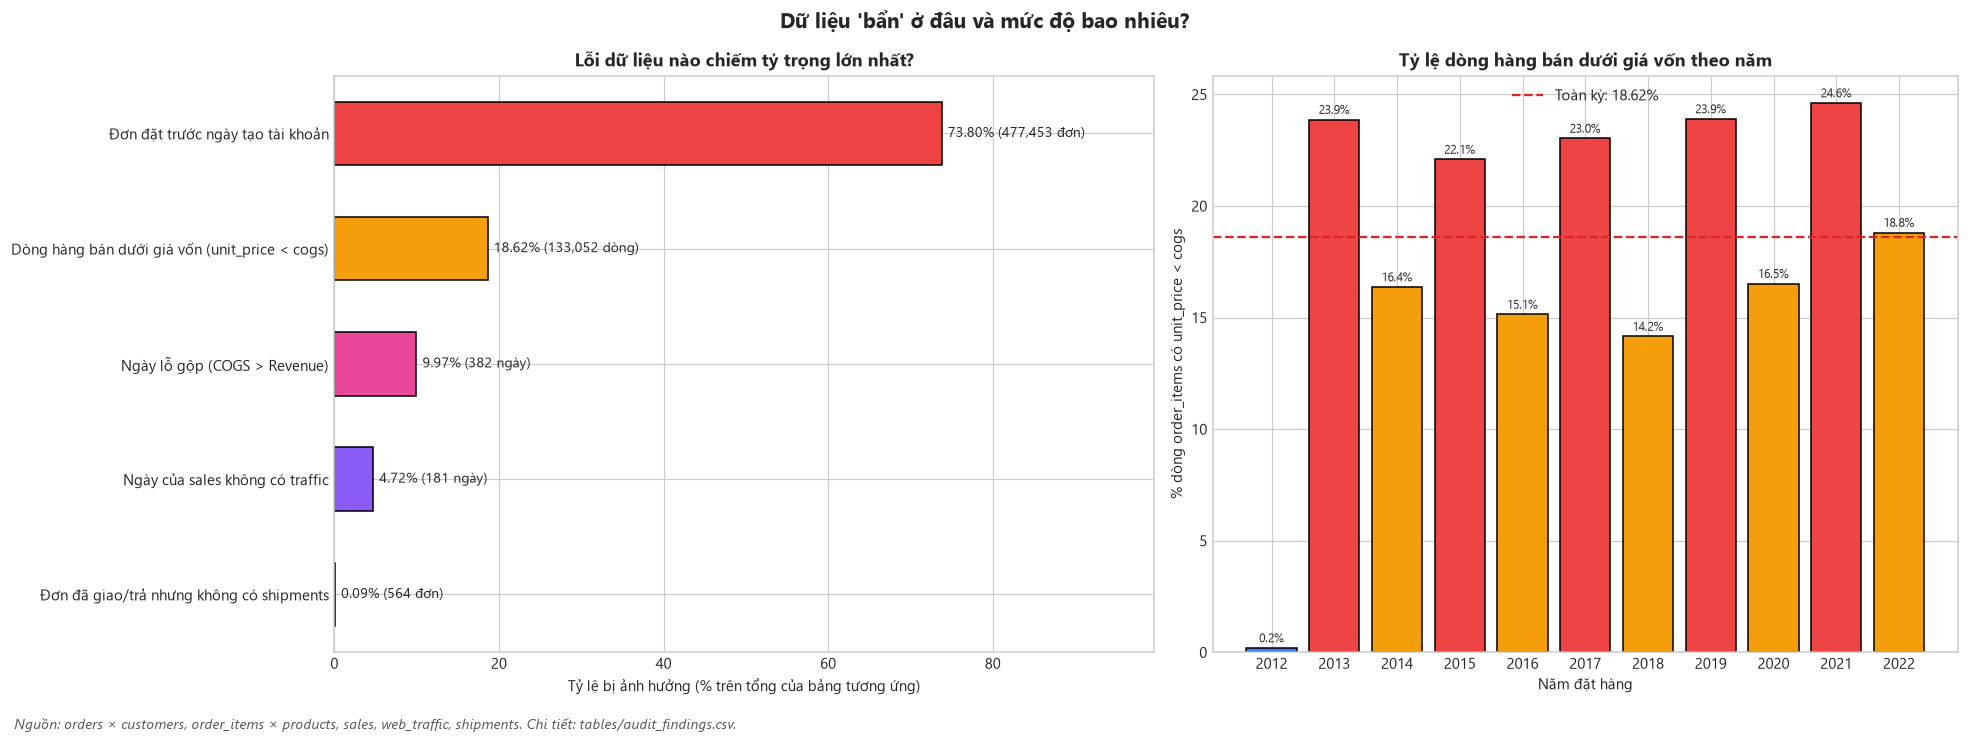

  đã lưu 06a_do_ban_du_lieu.png


In [4]:
n_b = int(m["before_signup"].sum())
issues = [
    ("Đơn đặt trước ngày tạo tài khoản", m["before_signup"].mean() * 100, f"{n_b:,} đơn"),
    ("Dòng hàng bán dưới giá vốn (unit_price < cogs)", m["below_cogs"].mean() * 100, f"{int(m['below_cogs'].sum()):,} dòng"),
    ("Ngày lỗ gộp (COGS > Revenue)", m["neg_profit_days"].mean() * 100, f"{int(m['neg_profit_days'].sum())} ngày"),
    ("Ngày của sales không có traffic", m["days_without_traffic"].mean() * 100, f"{int(m['days_without_traffic'].sum())} ngày"),
    ("Đơn đã giao/trả nhưng không có shipments", m["phantom_orders"].mean() * 100, f"{int(m['phantom_orders'].sum())} đơn"),
]
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), gridspec_kw={"width_ratios": [1.1, 1]})
y = np.arange(len(issues))[::-1]
bars = axes[0].barh(y, [i[1] for i in issues], color=["#ef4444", "#f59e0b", "#ec4899", "#8b5cf6", "#06b6d4"], edgecolor="black", height=0.55)
axes[0].bar_label(bars, labels=[f"{i[1]:.2f}% ({i[2]})" for i in issues], padding=4, fontsize=9)
axes[0].set_yticks(y, [i[0] for i in issues])
axes[0].set_xlim(0, max(i[1] for i in issues) * 1.35)
axes[0].set_xlabel("Tỷ lệ bị ảnh hưởng (% trên tổng của bảng tương ứng)")
axes[0].set_title("Lỗi dữ liệu nào chiếm tỷ trọng lớn nhất?", fontweight="bold")
yb = m["below_cogs_by_year"]
bars = axes[1].bar(yb.index.astype(str), yb.values, color=["#ef4444" if v > 20 else "#f59e0b" if v > 10 else "#3b82f6" for v in yb.values], edgecolor="black")
axes[1].bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
axes[1].axhline(m["below_cogs"].mean() * 100, color="#dc2626", ls="--", label=f"Toàn kỳ: {m['below_cogs'].mean() * 100:.2f}%")
axes[1].set_title("Tỷ lệ dòng hàng bán dưới giá vốn theo năm", fontweight="bold")
axes[1].set_xlabel("Năm đặt hàng")
axes[1].set_ylabel("% dòng order_items có unit_price < cogs")
axes[1].legend()
fig.suptitle("Dữ liệu 'bẩn' ở đâu và mức độ bao nhiêu?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Nguồn: orders × customers, order_items × products, sales, web_traffic, shipments. Chi tiết: tables/audit_findings.csv.")
save_fig(fig, FIG / "06a_do_ban_du_lieu.png")

In [5]:
key_numbers({
    "Đơn đặt trước ngày tạo tài khoản": f"{n_b:,} ({m['before_signup'].mean() * 100:.2f}%)",
    "Dòng bán dưới giá vốn": f"{m['below_cogs'].mean() * 100:.2f}% (năm cao nhất {yb.idxmax()}: {yb.max():.1f}%)",
    "Ngày lỗ gộp": f"{int(m['neg_profit_days'].sum())} ngày ({m['neg_profit_days'].mean() * 100:.2f}%)",
    "Dòng order_items có giá bán ≠ giá niêm yết": f"{findings.set_index('loai_loi').loc['Giá bán khác giá niêm yết', 'pct']:.2f}%",
})

Số liệu chính:
  - Đơn đặt trước ngày tạo tài khoản: 477,453 (73.80%)
  - Dòng bán dưới giá vốn: 18.62% (năm cao nhất 2021: 24.6%)
  - Ngày lỗ gộp: 382 ngày (9.97%)
  - Dòng order_items có giá bán ≠ giá niêm yết: 99.99%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## payments và sales.csv khớp với order_items theo cách nào?

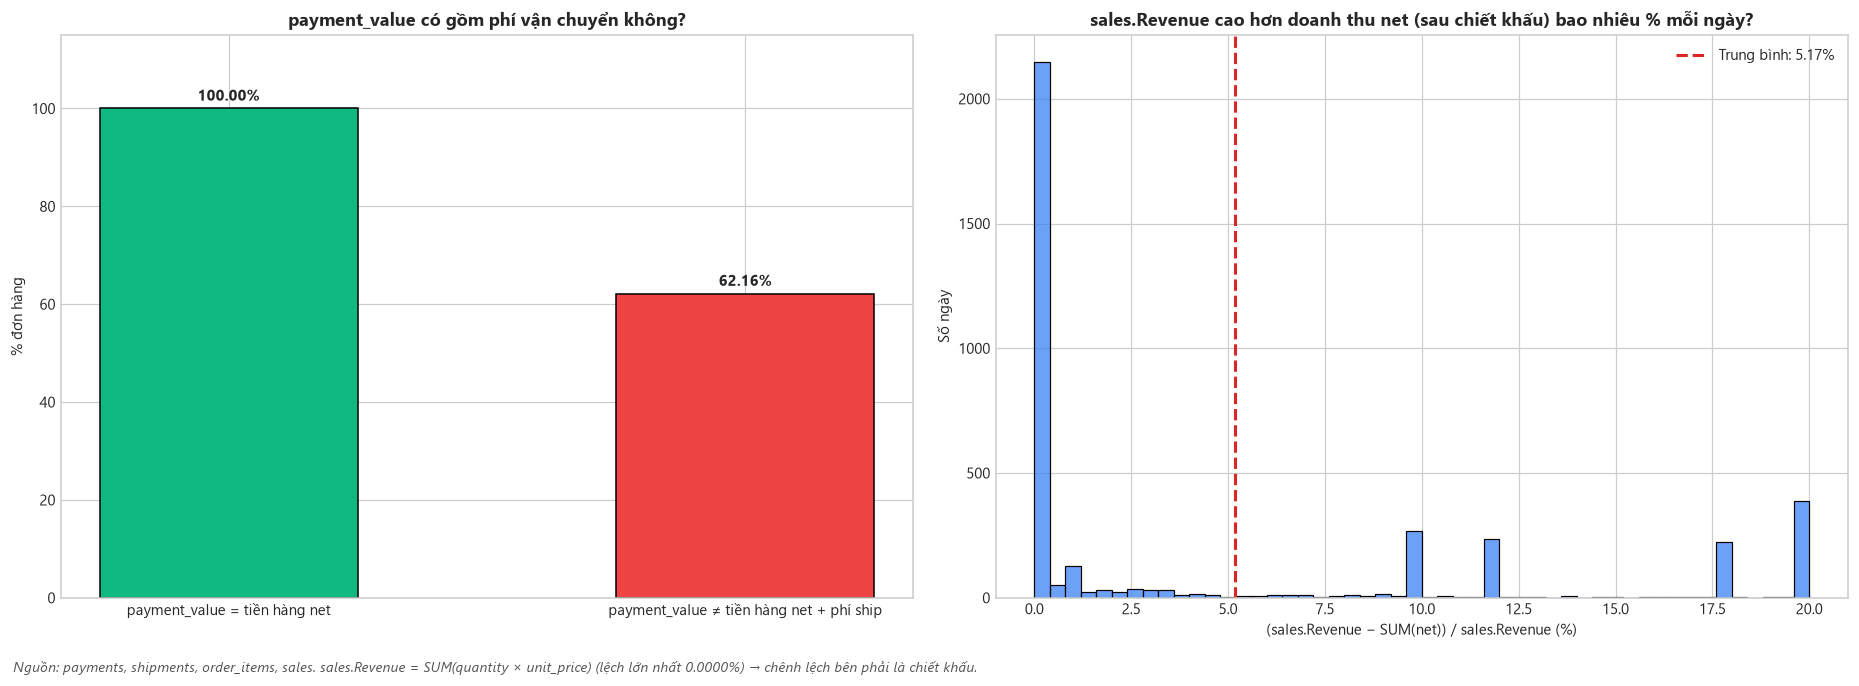

  đã lưu 06b_doi_soat_thanh_toan_doanh_thu.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
vals = [m["pay_match_items"].mean() * 100, m["pay_gap_with_ship"].mean() * 100]
bars = axes[0].bar(["payment_value = tiền hàng net", "payment_value ≠ tiền hàng net + phí ship"], vals,
                   color=["#10b981", "#ef4444"], edgecolor="black", width=0.5)
axes[0].bar_label(bars, fmt="%.2f%%", padding=3, fontweight="bold")
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("% đơn hàng")
axes[0].set_title("payment_value có gồm phí vận chuyển không?", fontweight="bold")
d = m["discount_pct_of_revenue"]
sns.histplot(d, bins=50, ax=axes[1], color="#3b82f6")
axes[1].axvline(d.mean(), color="#dc2626", ls="--", lw=2, label=f"Trung bình: {d.mean():.2f}%")
axes[1].set_title("sales.Revenue cao hơn doanh thu net (sau chiết khấu) bao nhiêu % mỗi ngày?", fontweight="bold")
axes[1].set_xlabel("(sales.Revenue − SUM(net)) / sales.Revenue (%)")
axes[1].set_ylabel("Số ngày")
axes[1].legend()
fig.tight_layout()
source_note(fig, f"Nguồn: payments, shipments, order_items, sales. sales.Revenue = SUM(quantity × unit_price) (lệch lớn nhất {m['max_gap_gross_pct']:.4f}%) → chênh lệch bên phải là chiết khấu.")
save_fig(fig, FIG / "06b_doi_soat_thanh_toan_doanh_thu.png")

In [7]:
key_numbers({
    "% đơn payment_value = tiền hàng net (±1)": f"{m['pay_match_items'].mean() * 100:.2f}%",
    "Số đơn lệch nếu cộng phí ship": f"{int(m['pay_gap_with_ship'].sum()):,} ({m['pay_gap_with_ship'].mean() * 100:.2f}%)",
    "sales.Revenue vs SUM(quantity × unit_price): lệch lớn nhất": f"{m['max_gap_gross_pct']:.4f}%",
    "sales.Revenue − doanh thu net: trung bình / trung vị": f"{d.mean():.2f}% / {d.median():.2f}%",
})

Số liệu chính:
  - % đơn payment_value = tiền hàng net (±1): 100.00%
  - Số đơn lệch nếu cộng phí ship: 402,126 (62.16%)
  - sales.Revenue vs SUM(quantity × unit_price): lệch lớn nhất: 0.0000%
  - sales.Revenue − doanh thu net: trung bình / trung vị: 5.17% / 0.00%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Chất lượng từng bảng theo 6 khía cạnh được bao nhiêu điểm (trước tiền xử lý)?

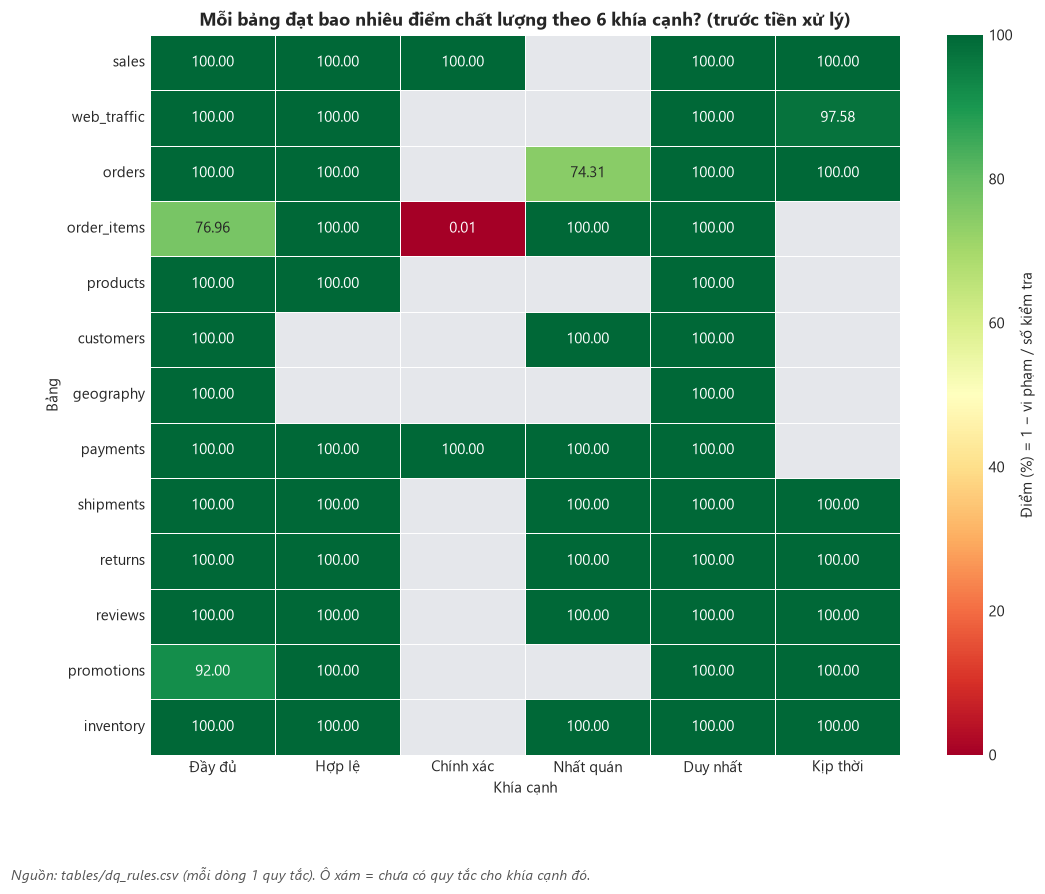

  đã lưu 06c_diem_6_khia_canh.png
Các quy tắc có vi phạm:


,bang,cot,khia_canh,quy_tac,so_kiem_tra,so_vi_pham,diem
115,order_items,unit_price,Chính xác,unit_price = products.price (±0.01),714669,714593,0.000106
24,order_items,promo_id_2,Đầy đủ,giá trị không trống,714669,714463,0.000288
72,promotions,applicable_category,Đầy đủ,giá trị không trống,50,40,0.200000
134,orders,order_date,Nhất quán,order_date >= customers.signup_date,646945,477453,0.261988
23,order_items,promo_id,Đầy đủ,giá trị không trống,714669,438353,0.386635
156,web_traffic,date,Kịp thời,mọi ngày của sales có dữ liệu traffic,3833,181,0.952779
135,orders,order_status,Nhất quán,đơn shipped/delivered/returned có bản ghi ship...,566631,564,0.999005
148,order_items,"order_id, product_id",Duy nhất,"khoá order_id, product_id không trùng",714669,16,0.999978


In [8]:
rules = dq_rules(t)
scores = dq_scores(rules)
rules.to_csv(TAB / "dq_rules.csv", index=False, encoding="utf-8-sig")
scores.to_csv(TAB / "dq_scores.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(11, 8.5))
ax.set_facecolor("#e5e7eb")       # ô xám = không có quy tắc áp dụng
ax.grid(False)
sns.heatmap(scores * 100, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=100, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Điểm (%) = 1 − vi phạm / số kiểm tra"}, ax=ax)
ax.set_title("Mỗi bảng đạt bao nhiêu điểm chất lượng theo 6 khía cạnh? (trước tiền xử lý)", fontweight="bold")
ax.set_xlabel("Khía cạnh")
ax.set_ylabel("Bảng")
source_note(fig, "Nguồn: tables/dq_rules.csv (mỗi dòng 1 quy tắc). Ô xám = chưa có quy tắc cho khía cạnh đó.")
save_fig(fig, FIG / "06c_diem_6_khia_canh.png")
print("Các quy tắc có vi phạm:")
rules[rules.so_vi_pham > 0].sort_values("diem")

In [9]:
print("Số quy tắc theo khía cạnh:", rules.khia_canh.value_counts().reindex(DIMENSIONS).to_dict())
low = scores.stack().nsmallest(4)
key_numbers({
    "Tổng số quy tắc / số quy tắc có vi phạm": f"{len(rules)} / {(rules.so_vi_pham > 0).sum()}",
    "4 ô điểm thấp nhất": ", ".join(f"{b} – {k}: {v * 100:.2f}%" for (b, k), v in low.items()),
    "Bảng đạt 100% mọi khía cạnh có quy tắc": ", ".join(scores.index[(scores.fillna(1) == 1).all(axis=1)]),
})

Số quy tắc theo khía cạnh: {'Đầy đủ': 93, 'Hợp lệ': 22, 'Chính xác': 4, 'Nhất quán': 17, 'Duy nhất': 13, 'Kịp thời': 9}
Số liệu chính:
  - Tổng số quy tắc / số quy tắc có vi phạm: 158 / 8
  - 4 ô điểm thấp nhất: order_items – Chính xác: 0.01%, orders – Nhất quán: 74.31%, order_items – Đầy đủ: 76.96%, promotions – Đầy đủ: 92.00%
  - Bảng đạt 100% mọi khía cạnh có quy tắc: sales, products, customers, geography, payments, shipments, returns, reviews, inventory


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Vấn đề phương pháp cần nhóm quyết

- **Đầy đủ của `order_items`**: `promo_id` / `promo_id_2` trống nghĩa là "không có khuyến mãi" (trống có chủ đích), không phải thiếu dữ liệu. Có tính là vi phạm không?
- **Chính xác của `order_items.unit_price`**: 99.99% dòng khác `products.price` – giá niêm yết sai, hay giá bán thay đổi theo thời gian / khuyến mãi (xem notebook 03)?
- **Nhất quán `orders.order_date ≥ customers.signup_date`**: 73.8% đơn vi phạm – `signup_date` có đáng tin để dùng làm đặc trưng không?
- Trọng số giữa các quy tắc: hiện điểm mỗi ô = 1 − tổng vi phạm / tổng số kiểm tra (quy tắc nhiều dòng nặng hơn).